In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
'''Loading Cleaned Data'''
df_clean = pd.read_excel('2_Railway_Featured.xlsx')

In [3]:
df_clean.head()

,PNR Number,Train Number,Date of Journey,Class of Travel,Quota,Source Station,Destination Station,Booking Date,Current Status,Number of Passengers,...,Booking Lead Time,Waitlist Number,Route,Journey Month,Journey Day,Journey Year,Waitlist Category,Booking Lead Time Category,Distance Category,Passenger Group Size
0,PNR0000000000,51450,2024-09-01,3AC,General,NDLS,CSMT,2024-01-01,Confirmed,4,...,244,0,NDLS->CSMT,September,Sunday,2024,No WL,90+ Days,Very Long,3-4 Passengers
1,PNR0000000001,54807,2024-09-02,3AC,Premium Tatkal,MMCT,LTT,2024-01-02,Waitlisted,5,...,244,97,MMCT->LTT,September,Monday,2024,WL 51-100,90+ Days,Very Long,5+ Passengers
2,PNR0000000002,14396,2024-09-03,3AC,Ladies,GKP,BBS,2024-01-03,RAC,5,...,244,0,GKP->BBS,September,Tuesday,2024,No WL,90+ Days,Short,5+ Passengers
3,PNR0000000003,20295,2024-09-04,3AC,Ladies,ASR,KOAA,2024-01-04,Waitlisted,1,...,244,11,ASR->KOAA,September,Wednesday,2024,WL 11-50,90+ Days,Very Long,1 Passenger
4,PNR0000000004,48598,2024-09-05,2AC,Tatkal,MAS,SBC,2024-01-05,Confirmed,3,...,244,0,MAS->SBC,September,Thursday,2024,No WL,90+ Days,Very Long,3-4 Passengers


In [4]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   PNR Number                  30000 non-null  str           
 1   Train Number                30000 non-null  int64         
 2   Date of Journey             30000 non-null  datetime64[us]
 3   Class of Travel             30000 non-null  str           
 4   Quota                       30000 non-null  str           
 5   Source Station              30000 non-null  str           
 6   Destination Station         30000 non-null  str           
 7   Booking Date                30000 non-null  datetime64[us]
 8   Current Status              30000 non-null  str           
 9   Number of Passengers        30000 non-null  int64         
 10  Age of Passengers           30000 non-null  str           
 11  Booking Channel             30000 non-null  str           
 12  T

In [5]:
'''We can see that our category data type converted into string for csv as it dosent hai that function so we convert into category again'''

df_clean['Waitlist Category'] = df_clean['Waitlist Category'].astype('category')
df_clean['Booking Lead Time Category'] = df_clean['Booking Lead Time Category'].astype('category')
df_clean['Distance Category'] = df_clean['Distance Category'].astype('category')
df_clean[ 'Passenger Group Size'] = df_clean[ 'Passenger Group Size'].astype('category')

In [6]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   PNR Number                  30000 non-null  str           
 1   Train Number                30000 non-null  int64         
 2   Date of Journey             30000 non-null  datetime64[us]
 3   Class of Travel             30000 non-null  str           
 4   Quota                       30000 non-null  str           
 5   Source Station              30000 non-null  str           
 6   Destination Station         30000 non-null  str           
 7   Booking Date                30000 non-null  datetime64[us]
 8   Current Status              30000 non-null  str           
 9   Number of Passengers        30000 non-null  int64         
 10  Age of Passengers           30000 non-null  str           
 11  Booking Channel             30000 non-null  str           
 12  T

In [7]:
'''EDA (Exploratory Data Analysis) :- What is happening in the railway booking business, and why?

EDA means: Exploring your data to find patterns, problems, relationships, and useful insights'''

'EDA (Exploratory Data Analysis) :- What is happening in the railway booking business, and why?\n\nEDA means: Exploring your data to find patterns, problems, relationships, and useful insights'

In [8]:
df_clean.columns  #For viewing

Index(['PNR Number', 'Train Number', 'Date of Journey', 'Class of Travel',
       'Quota', 'Source Station', 'Destination Station', 'Booking Date',
       'Current Status', 'Number of Passengers', 'Age of Passengers',
       'Booking Channel', 'Travel Distance', 'Number of Stations',
       'Travel Time', 'Train Type', 'Seat Availability',
       'Special Considerations', 'Holiday or Peak Season', 'Waitlist Position',
       'Confirmation Status', 'Was Waitlisted', 'Booking Lead Time',
       'Waitlist Number', 'Route', 'Journey Month', 'Journey Day',
       'Journey Year', 'Waitlist Category', 'Booking Lead Time Category',
       'Distance Category', 'Passenger Group Size'],
      dtype='str')

In [9]:
'''Question 1: How many bookings do we have?'''

total_bookings = df_clean.shape[0]
print("Total Bookings:",total_bookings)

Total Bookings: 30000


In [10]:
'''Question 2: How many passengers?'''

total_passengers = df_clean['Number of Passengers'].sum()
print("Total Passengers:",total_passengers)     # Bookings ≠ Passengers, One booking could contain multiple passengers.

Total Passengers: 90181


In [11]:
'''Question 3: What is the confirmation status distribution %?'''

'Question 3: What is the confirmation status distribution %?'

In [12]:
df_clean['Confirmation Status'].value_counts()

confirmation_percent = (df_clean['Confirmation Status'].value_counts(normalize=True) * 100)
print(confirmation_percent) #Overall, 66.49% of bookings were confirmed, while 33.51% were not confirmed. This indicates that approximately one-third of bookings in the dataset did not reach confirmed status.

Confirmation Status
Confirmed        66.49
Not Confirmed    33.51
Name: proportion, dtype: float64


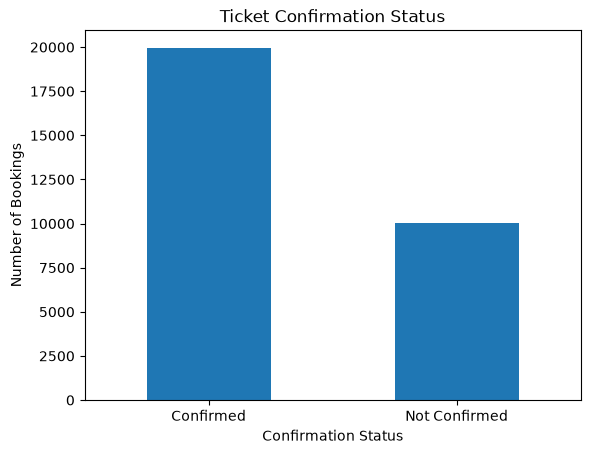

In [13]:
df_clean["Confirmation Status"].value_counts().plot(kind="bar",title="Ticket Confirmation Status")

plt.xlabel("Confirmation Status")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.show() #What proportion of bookings are successfully confirmed

In [14]:
'''Does travel class have a relationship with confirmation?'''

'Does travel class have a relationship with confirmation?'

In [15]:
class_confirmation = pd.crosstab(
    df_clean["Class of Travel"],
    df_clean["Confirmation Status"]
)

class_confirmation

Confirmation Status,Confirmed,Not Confirmed
Class of Travel,,
1AC,4977,2505
2AC,4948,2497
3AC,4995,2465
Sleeper,5027,2586


In [16]:
class_confirmation_rate = pd.crosstab(
    df_clean["Class of Travel"],
    df_clean["Confirmation Status"],
    normalize="index"
) * 100

class_confirmation_rate = class_confirmation_rate.round(2)
class_confirmation_rate

Confirmation Status,Confirmed,Not Confirmed
Class of Travel,,
1AC,66.52,33.48
2AC,66.46,33.54
3AC,66.96,33.04
Sleeper,66.03,33.97


In [17]:
'''Which travel class has the highest confirmation rate?'''

'Which travel class has the highest confirmation rate?'

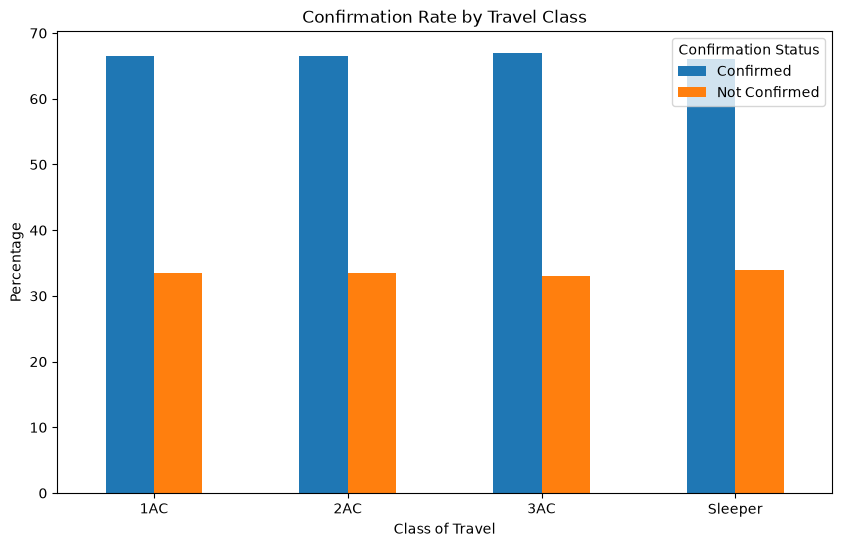

In [18]:
class_confirmation_rate.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Confirmation Rate by Travel Class")
plt.xlabel("Class of Travel")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Confirmation Status")
plt.show()

In [19]:
'''Does booking quota have a relationship with confirmation?'''

'Does booking quota have a relationship with confirmation?'

In [20]:
quota_confirmation = pd.crosstab(
    df_clean["Quota"],
    df_clean["Confirmation Status"],
    normalize="index"
) * 100

quota_confirmation

Confirmation Status,Confirmed,Not Confirmed
Quota,,
General,67.017731,32.982269
Ladies,66.257348,33.742652
Premium Tatkal,66.500000,33.500000
Tatkal,66.187534,33.812466


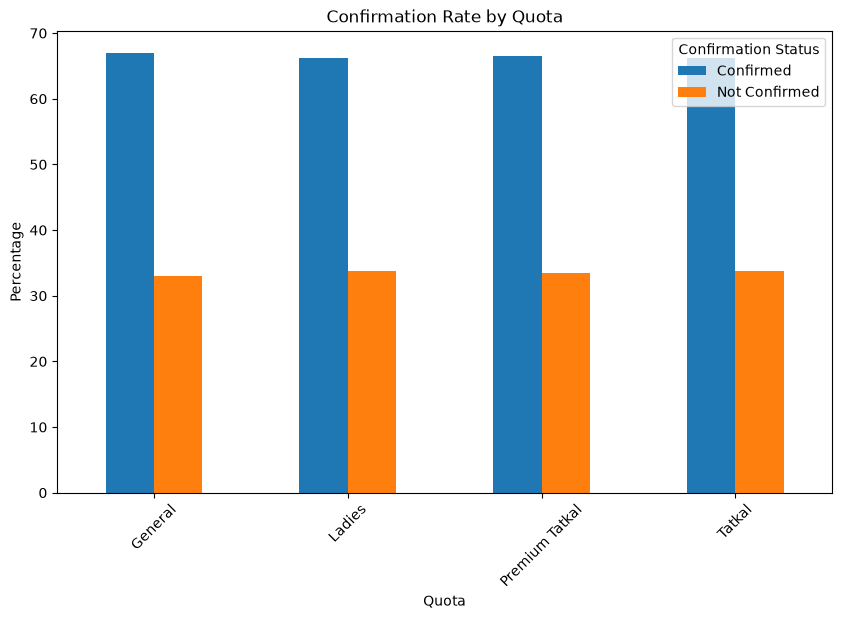

In [21]:
quota_confirmation.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Confirmation Rate by Quota")
plt.xlabel("Quota")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()
#You may find that some quotas have:
#higher confirmation
#lower confirmation
#much higher demand

In [22]:
'''Does booking channel show different confirmation patterns?'''

'Does booking channel show different confirmation patterns?'

In [23]:
channel_confirmation = pd.crosstab(
    df_clean["Booking Channel"],
    df_clean["Confirmation Status"],
    normalize="index"
) * 100

channel_confirmation

Confirmation Status,Confirmed,Not Confirmed
Booking Channel,,
Counter,65.794505,34.205495
IRCTC Website,66.792829,33.207171
Mobile App,66.876185,33.123815


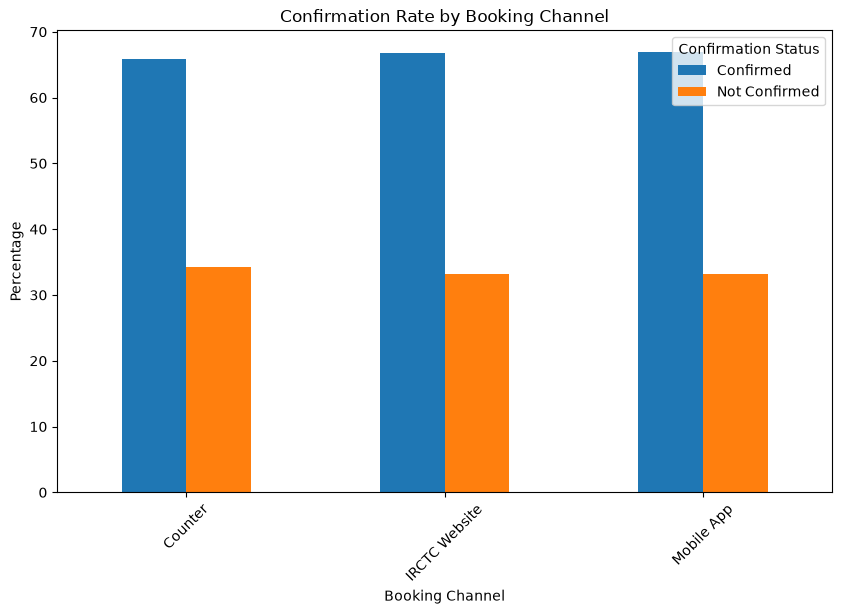

In [24]:
channel_confirmation.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Confirmation Rate by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

#The website shows a higher confirmation rate in this dataset.

In [25]:
'''Does booking earlier relate to a higher chance of confirmation?'''

'Does booking earlier relate to a higher chance of confirmation?'

In [26]:
lead_time_confirmation = pd.crosstab(
    df_clean["Booking Lead Time Category"],
    df_clean["Confirmation Status"],
    normalize="index"
) * 100

lead_time_confirmation

Confirmation Status,Confirmed,Not Confirmed
Booking Lead Time Category,,
90+ Days,66.49,33.51


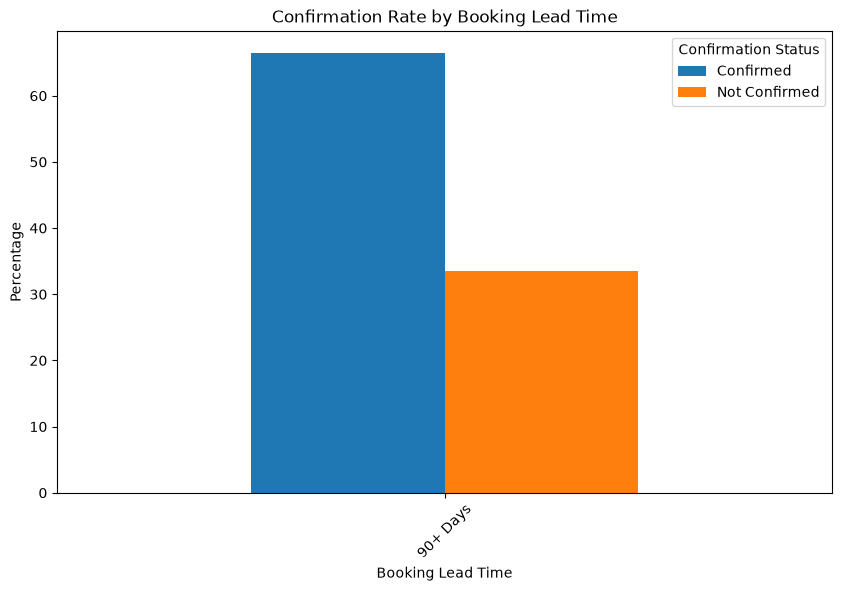

In [27]:
lead_time_confirmation.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Confirmation Rate by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

In [28]:
'''Waitlist analysis'''

'''How does confirmation differ between passengers who were and were not waitlisted?'''

'How does confirmation differ between passengers who were and were not waitlisted?'

In [29]:
df_clean["Was Waitlisted"].value_counts()

Was Waitlisted
False    19947
True     10053
Name: count, dtype: int64

In [30]:
waitlist_confirmation = pd.crosstab(
    df_clean["Was Waitlisted"],
    df_clean["Confirmation Status"],
    normalize="index"
) * 100

waitlist_confirmation

Confirmation Status,Confirmed,Not Confirmed
Was Waitlisted,,
False,100.0,0.0
True,0.0,100.0


In [31]:
'''Waitlist position'''

'''Does a higher waitlist position correspond to a lower confirmation rate?'''

'Does a higher waitlist position correspond to a lower confirmation rate?'

In [32]:
waitlist_position_analysis = pd.crosstab(
    df_clean["Waitlist Category"],
    df_clean["Confirmation Status"],
    normalize="index"
) * 100

waitlist_position_analysis

Confirmation Status,Confirmed,Not Confirmed
Waitlist Category,,
No WL,100.0,0.0
WL 1-10,0.0,100.0
WL 100+,0.0,100.0
WL 11-50,0.0,100.0
WL 51-100,0.0,100.0


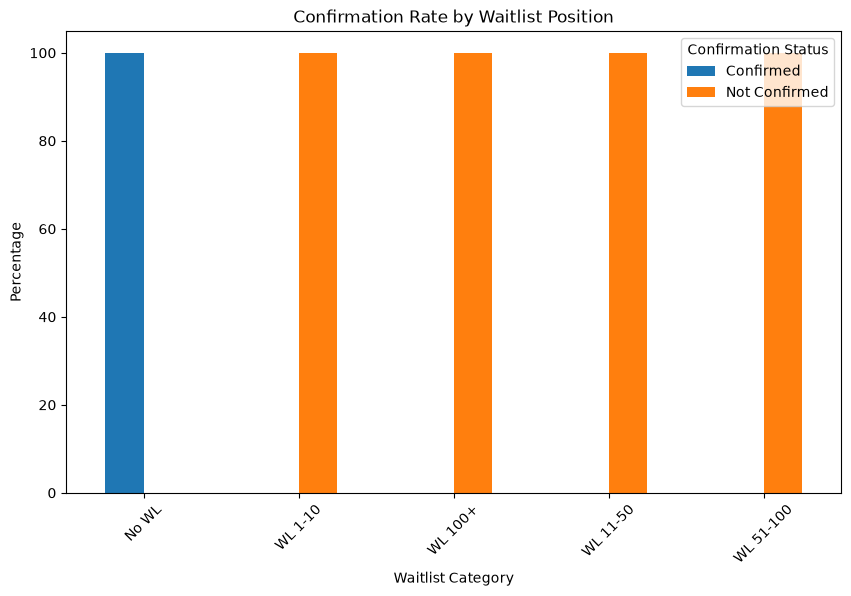

In [33]:
waitlist_position_analysis.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Confirmation Rate by Waitlist Position")
plt.xlabel("Waitlist Category")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

In [34]:
'''Does peak season affect ticket demand and confirmation?'''

'Does peak season affect ticket demand and confirmation?'

In [35]:
df_clean["Holiday or Peak Season"].value_counts()

Holiday or Peak Season
Yes    15089
No     14911
Name: count, dtype: int64

In [36]:
peak_confirmation = pd.crosstab(
    df_clean["Holiday or Peak Season"],
    df_clean["Confirmation Status"],
    normalize="index"
) * 100

peak_confirmation

Confirmation Status,Confirmed,Not Confirmed
Holiday or Peak Season,,
No,66.823151,33.176849
Yes,66.160779,33.839221


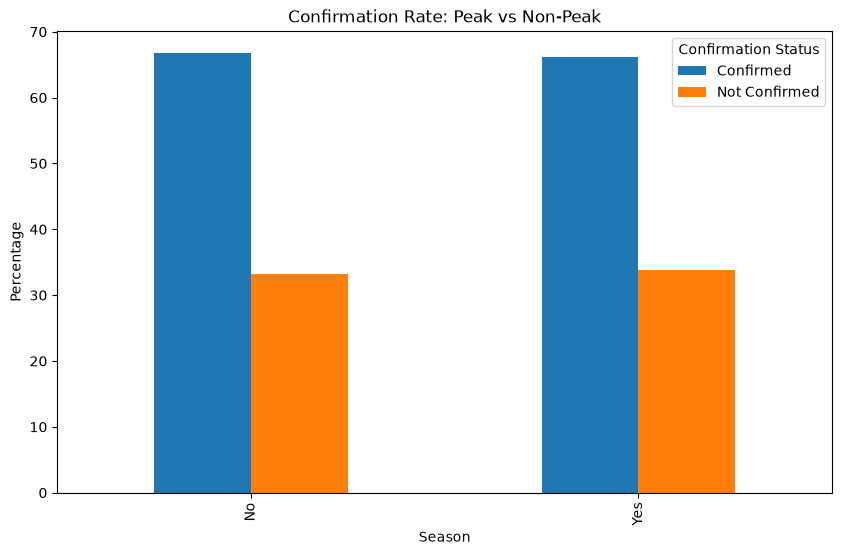

In [37]:
peak_confirmation.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Confirmation Rate: Peak vs Non-Peak")
plt.xlabel("Season")
plt.ylabel("Percentage")
plt.show()

In [38]:
'''Now let's understand when demand is highest.'''

"Now let's understand when demand is highest."

In [39]:
monthly_bookings = (
    df_clean
    .groupby("Journey Month")
    .size()
)

monthly_bookings

Journey Month
April        2460
August       2542
December     2542
February     2315
January      2542
July         2542
June         2460
March        2542
May          2542
November     2460
October      2563
September    2490
dtype: int64

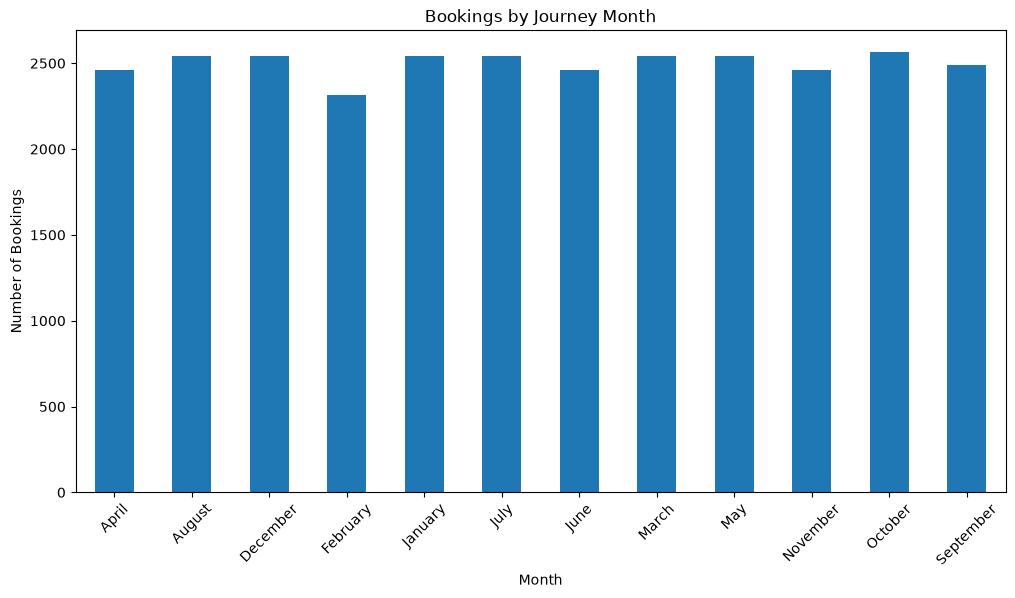

In [40]:
monthly_bookings.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Bookings by Journey Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

In [41]:
'''Which days have the highest booking demand?'''

'Which days have the highest booking demand?'

In [42]:
day_bookings = (
    df_clean
    .groupby("Journey Day")
    .size()
)

day_bookings

Journey Day
Friday       4285
Monday       4286
Saturday     4285
Sunday       4286
Thursday     4286
Tuesday      4286
Wednesday    4286
dtype: int64

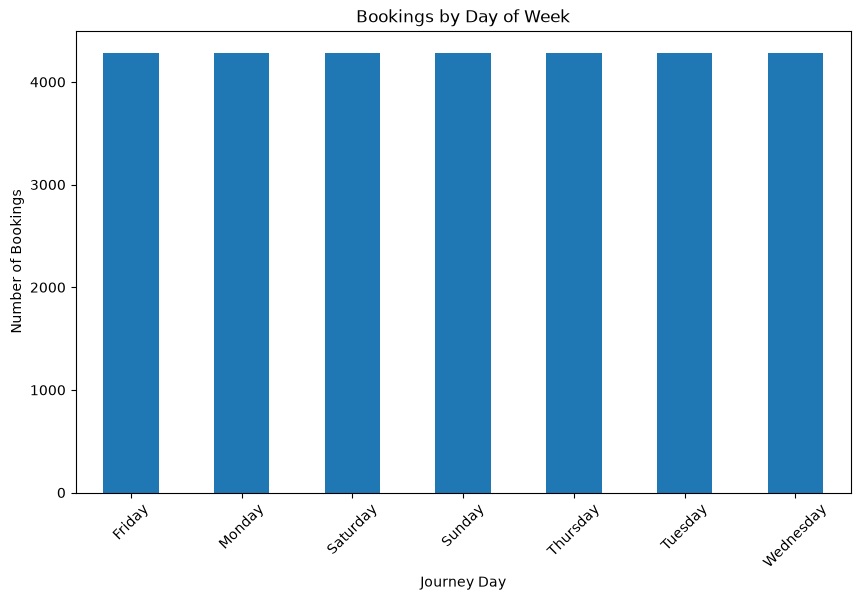

In [43]:
day_bookings.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Bookings by Day of Week")
plt.xlabel("Journey Day")
plt.ylabel("Number of Bookings")
plt.xticks(rotation = 45)
plt.show()

In [44]:
'''which trains have the highest number of bookings in your dataset.'''

'which trains have the highest number of bookings in your dataset.'

In [45]:
top_trains = (
    df_clean["Train Number"]
    .value_counts()
    .head(10)
)

top_trains

Train Number
49540    5
90260    5
54196    5
61441    5
89496    5
15496    4
78244    4
32235    4
33004    4
81060    4
Name: count, dtype: int64

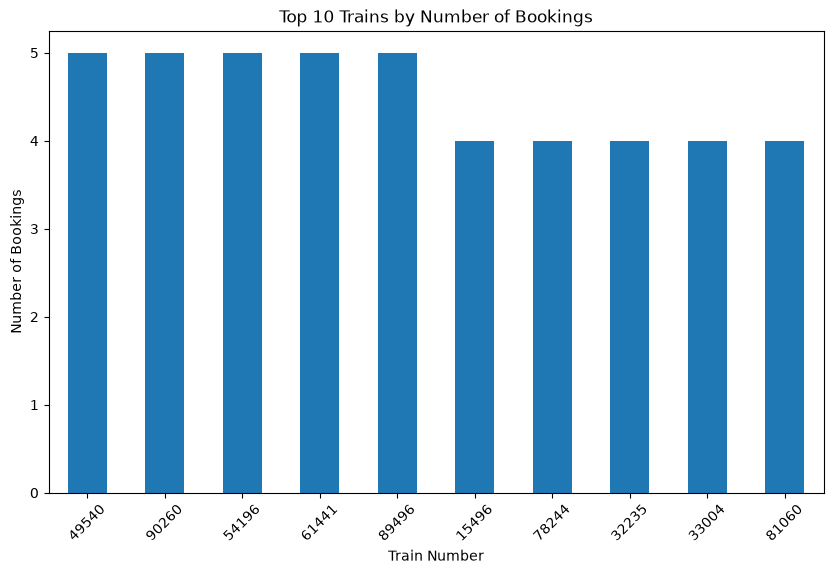

In [46]:
top_trains.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Top 10 Trains by Number of Bookings")
plt.xlabel("Train Number")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

In [47]:
'''Top 10 routes'''

'Top 10 routes'

In [48]:
top_routes = (
    df_clean["Route"]
    .value_counts()
    .head(10)
)

top_routes

Route
KOAA->SC      80
GKP->LTT      79
LKO->MAS      78
BCT->LTT      77
GKP->JHS      76
BCT->MMCT     76
SC->LTT       75
BBS->KOAA     75
SC->UMB       74
PNBE->NDLS    73
Name: count, dtype: int64

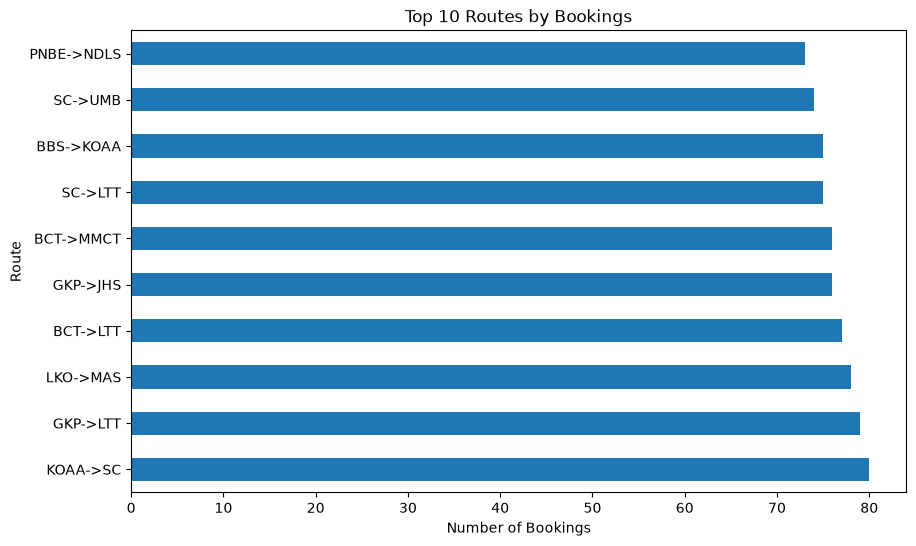

In [49]:
top_routes.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Routes by Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Route")
plt.show()

In [50]:
'''Trains with the lowest average availability'''

'Trains with the lowest average availability'

In [51]:
df_clean["Seat Availability"].describe()

count    30000.000000
mean       248.493767
std        144.248284
min          0.000000
25%        124.000000
50%        248.000000
75%        373.000000
max        499.000000
Name: Seat Availability, dtype: float64

In [52]:
low_availability_trains = (
    df_clean
    .groupby("Train Number")["Seat Availability"]
    .mean()
    .sort_values()
    .head(10)
)

low_availability_trains

Train Number
85402    0.0
76340    0.0
63370    0.0
61950    0.0
26469    0.0
12184    0.0
61829    0.0
16888    0.0
99402    0.0
11327    0.0
Name: Seat Availability, dtype: float64

In [53]:
class_confirmation_rate

Confirmation Status,Confirmed,Not Confirmed
Class of Travel,,
1AC,66.52,33.48
2AC,66.46,33.54
3AC,66.96,33.04
Sleeper,66.03,33.97
